**Question 4.1**

In [1]:
x = [1,2,3,10]
y = [10, 20, 30, 40]
new_list = []
for i in zip(x,y):
    new_list.append(sum(i))
new_list

[11, 22, 33, 50]

In [2]:
newer_list = [sum(i) for i in zip(x,y)]
newer_list

[11, 22, 33, 50]

In [3]:
even_newer_list = list(map(sum,zip(x,y)))
even_newer_list

[11, 22, 33, 50]

**Question 4.3**

In [4]:
import numpy as np
game_on = True
def game():
    """One round of rock-paper-scissors"""
    
    signs = ['R','P','S']
    sign = input('Type R for rock, P for paper or S for scissors:').upper()   # gets the sign and converts it to a capital letter (if someone hits lowercase)
    if not(sign in signs):                                                    # checks if the given sign is valid : quits if not
        return "Error"
    
    generated = signs[np.random.randint(0,2)]                                 # if the user input is valid, the code continues to run : generating the machine's sign
    print(f"Machine says: {generated}")
    if sign == 'S' and generated == 'R':                                      # machine's rock beats user's scissors
        return "Machine"
    elif signs.index(sign) == signs.index(generated)-1:                       # R loses to P, P loses to S : Machine wins 
        return "Machine"
    elif signs.index(sign) == signs.index(generated)+1:                       # P wins to R, S wins to P : User wins
        return "User"
    elif signs.index(sign) == signs.index(generated):                         # if the two signs are equal : draw
        return "Draw"

while game_on:
    print(game(),"won this round.")                                           # result of a round
    next_ = input("Do you want to continue? [y/n]").upper()                   # asks for next round
    if next_ == 'N':
        game_on = False                                                       # stops loop upon request
    elif next_ == 'Y':
        pass
    else:
        while next_ != 'Y' and next_ != 'N':
            next_ = input("Input cannot be comprehended, please type 'y' or 'n'!").upper()
print("Thank you for playing!")

Type R for rock, P for paper or S for scissors: s


Machine says: R
Machine won this round.


Do you want to continue? [y/n] n


Thank you for playing!


**Question 4.4**

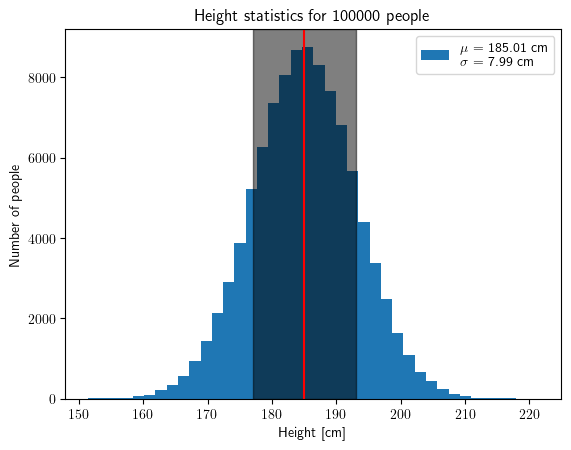

The mean of the dataset is 185.01268305267925, which differs by 0.012683052679250295 from the original parameter.
The standard deviation of the dataset is 7.9887552861607, which differs by -0.011244713839300147 from the original parameter.


Input a height (h): 180


A random point in the dataset has a 26.52% chanche for being less than h.
A random height has a 68.27% chanche for being less than 1 sigma far from the mean.


In [26]:
import matplotlib.pyplot as plt
from scipy import stats, sparse
data = np.random.normal(185,8,100000)

plt.rc("text",usetex=True)
plt.hist(data, bins = 40, label=f"$\mu$ = {np.mean(data):.2f} cm \n$\sigma$ = {np.std(data):.2f} cm")
plt.xlabel("Height [cm]")
plt.ylabel("Number of people")
plt.title("Height statistics for 100000 people")
plt.legend()
plt.axvline(x = np.mean(data), color = 'red')
plt.axvspan(np.mean(data)-np.std(data), np.mean(data)+np.std(data), color = 'black', alpha = 0.5)
plt.show()

print(f"The mean of the dataset is {np.mean(data)}, which differs by {np.mean(data)-185} from the original parameter.")
print(f"The standard deviation of the dataset is {np.std(data)}, which differs by {np.std(data)-8} from the original parameter.")

h = float(input("Input a height (h):"))
print(f"A random point in the dataset has a {stats.norm.cdf(h, np.mean(data), np.std(data))*100:.2f}% chanche for being less than h.")
print(f"A random height has a {(stats.norm.cdf(np.mean(data)+np.std(data),np.mean(data), np.std(data))-stats.norm.cdf(np.mean(data)-np.std(data),np.mean(data), np.std(data)))*100:.2f}% chanche for being less than 1 sigma far from the mean.")

**Question 4.6**

In [45]:
from numpy import *
fun = input("Input a function:")
xmin = float(input("Input the lower bound:"))
xmax = float(input("Input the upper bound:"))
n = 100000
x = random.uniform(xmin,xmax,n)
y = eval(fun)

integral = sum(y)*(xmax-xmin)/n
print(integral)

Input a function: x**2
Input the lower bound: 0
Input the upper bound: 1


0.33219716763354656


**Question 4.12**

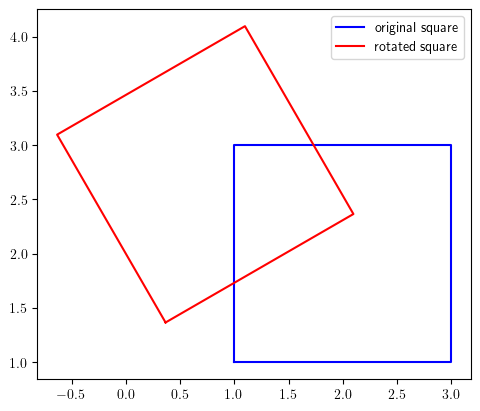

In [7]:
angle = 30
angle = radians(angle)
rotor = cos(angle)+1j*sin(angle)

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])
r = x + y*1j

x1 = (rotor*r).real
y1 = (rotor*r).imag

plt.plot(x,y,color='blue', label = 'original square')
plt.plot(x1,y1,color='red', label = 'rotated square')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()

**Question 4.14**

In [8]:
import numpy as np
def funcfilter(func,seq):
    seq = np.asarray(seq)
    x = []
    for i in seq:
        if i > 0:
            x.append(i)
    return func(np.array(x))

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

Result log10: [1. 2.]


**Question 4.16**

In [9]:
from astropy.cosmology import Planck18
import scipy
import math

H0 = Planck18.H0.value/(3.086e+19)
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

z = 2

def F(x):
    f = H0*math.sqrt(Om0*(1+x)**3+Ode0)*(1+x)
    return 1/f

integral = scipy.integrate.quad(F,0,z)[0]
in_Gy = integral/(3600*24*365*10**9)

print(f"For z = {z}, the lookback time is {in_Gy:.2f} Gyr.")

For z = 2, the lookback time is 10.53 Gyr.


**Question 4.21**

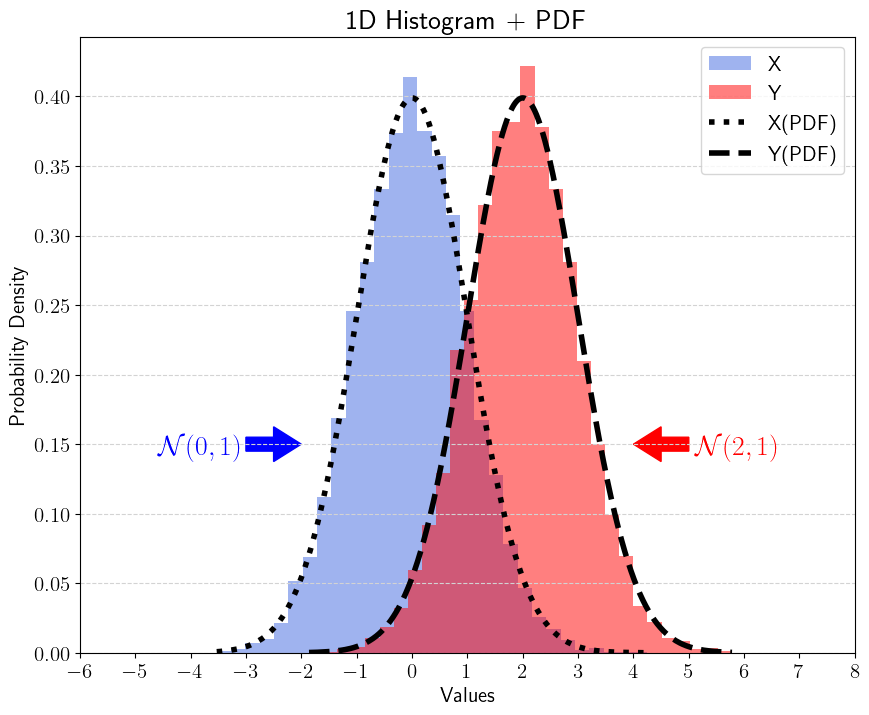

In [85]:
set1 = np.random.normal(0,1,10000)
set2 = np.random.normal(2,1,10000)

set1 = np.array(set1,dtype=np.dtype(np.float16))    # for memory resons
set2 = np.array(set2,dtype=np.dtype(np.float16))    # for memory resons

pdf1 = stats.norm.pdf(np.sort(set1), 0, 1)
pdf2 = stats.norm.pdf(np.sort(set2), 2, 1)

label1 = "X"
label2 = "Y"
label1_pdf = "X(PDF)"
label2_pdf = "Y(PDF)"


plt.figure(figsize=(10,8))
plt.hist(set1, density = True, bins = 30, label=label1, color='royalblue', ec = 'k',alpha = 0.5)
plt.hist(set2, density = True, bins = 30, label=label2, color='red',ec = 'k', alpha = 0.5)
plt.plot(np.sort(set1),pdf1, color='black', linewidth = 4,label=label1_pdf, linestyle = ":")
plt.plot(np.sort(set2),pdf2, color='black', linewidth = 4,label=label2_pdf, linestyle = "--")

#plt.rc("text", usetex = True)
plt.xlim(-6,8)
plt.xticks(range(-6,9), fontsize = 15)
plt.yticks(fontsize = 15)

plt.title('1D Histogram + PDF', fontsize = 20)
plt.xlabel("Values", fontsize = 15)
plt.ylabel("Probability Density", fontsize = 15)

plt.arrow(5, 0.15, -.5, 0, width=0.01, head_length = 0.5, head_width = 0.025, color="red")
plt.annotate(r'$\mathcal{N}(2,1)$',xy=(5.1, 0.143), color = 'red',fontsize = 20)

plt.arrow(-3, 0.15, .5, 0, width=0.01, head_length = 0.5, head_width = 0.025, color="blue")
plt.annotate(r'$\mathcal{N}(0,1)$',xy=(-4.6, 0.143), color = 'blue',fontsize = 20)

plt.grid(axis = 'y',color = 'lightgrey', linestyle = '--')
plt.legend(fontsize = 15)

plt.show()

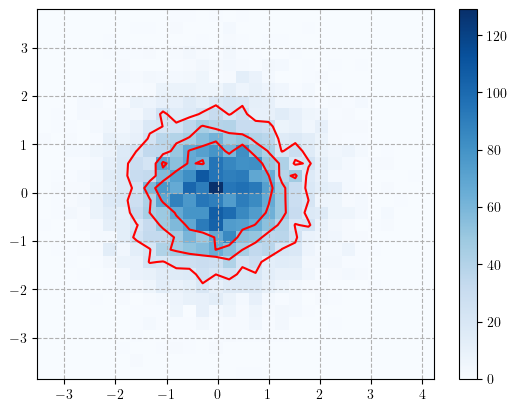

In [86]:
H, xedges, yedges, image  = plt.hist2d(set1,set2-np.mean(set2), bins = 30,cmap = 'Blues')
plt.colorbar()

H = H.T
x = (xedges[:-1] + xedges[1:]) / 2
y = (yedges[:-1] + yedges[1:]) / 2
Xc, Yc = np.meshgrid(x, y)

level = [np.std(H),np.std(H)*2,np.std(H)*3]
CS = plt.contour(Xc, Yc, H, levels=level, colors = 'red')
plt.grid(linestyle = '--')

plt.show()